# Brightness conversion

In [1]:
# packages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from astropy.io import fits
from astropy import units as u
import os 
import scopesim as sim

# custom functions
from functions import *
from variables import *

py.warnings - WARNING: c:\Users\Nyota\OneDrive - Universite de Liege\MASTER 3\TFE_AGN\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



In [2]:
# Changement of folder (needed to work with ScopeSim)
os.chdir("ScopeSim") #relative path to ScopeSim folder
print(os.getcwd())

c:\Users\Nyota\OneDrive - Universite de Liege\MASTER 3\TFE_AGN\Code\ScopeSim


## Conversion Jy to ADU

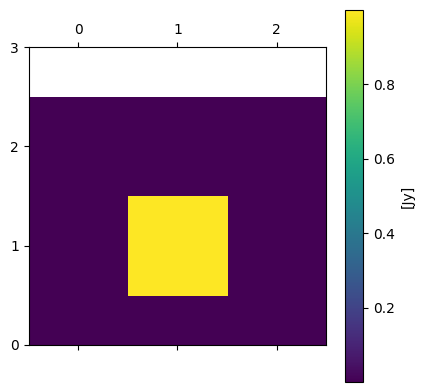

In [36]:
#pixel_size_circinus = 0.1*u.pc
#D_circinus = 4.2 *u.Mpc
pixel_size_circinus = mas_to_pc(N_band_pixel_scale, D_circinus)

FWHM_unres = mas_to_pc(N_band_pixel_scale/2, D_circinus)

flux_pt = 1*u.Jy

pt_source_1 = Circular_Gaussian_profile(FWHM=FWHM_unres, flux=flux_pt, 
                                      pixel_size=pixel_size_circinus, D_source=D_circinus,
                                      example_file=example_FITS, band_name='N', source_name='unres_pt_source_'+str(flux_pt.value)+'Jy', 
                                      creating_FITS=True)

plt.matshow(pt_source_1)
plt.ylim(0, np.shape(pt_source_1)[1])
plt.colorbar(label='[Jy]')
plt.show()

In [4]:
print(np.sum(pt_source_1))

1.0


### Without chop nod

In [45]:
def SNR_calculation(object_name, file_src,  
                    mode, exptime, window_lim, file_full_src,
                    chop_nod, chop_nod_offset,
                    psf_substraction, psf_file, 
                    SNR_implane_plot, SNR_readout_plot, 
                    contour_plot,
                    creating_FITs): 
    
    if mode == "img_n":
        band = "N-band"
    if mode == "img_lm":
        band = "L-band"
    
    # METIS set up
    cmd = sim.UserCommands(use_instrument="METIS", set_modes=[mode], properties={"!OBS.exptime": exptime.value, "!OBS.dit": None, "!OBS.ndit": None})
    metis = sim.OpticalTrain(cmd)
    
    # Sky observation
    metis.observe()      # blank sky
    
    sky_implane = metis.image_planes[0].data # [ph/s]
    sky_readout = metis.readout(exptime=exptime.value)[0]
    sky_readout_data = sky_readout[1].data
    dit, ndit = metis.cmds["!OBS.dit"], metis.cmds["!OBS.ndit"]
    
    # PSF substraction
    if psf_substraction == True:
        psf_implane, psf_readout, psf_readout_data, header_psf_implane, header_psf_readout = METIS_observation(psf_file, chop_nod_offset, metis, dit, ndit, chop_nod)
        if chop_nod == True:
            psf_chop_nod = chop_nod_fct(psf_readout, chop_nod_offset, dit, ndit*4, mode)
            
    # Object observation
    src_implane, src_readout, src_readout_data, header_src_implane, header_src_readout  = METIS_observation(file_src, chop_nod_offset, metis, dit, ndit, chop_nod)
    if chop_nod == True:
        bgsub_readout = chop_nod_fct(src_readout, chop_nod_offset, dit, ndit*4, mode) 
        
        
    # Background substraction 
    if chop_nod == False and psf_substraction == False:
        bgsub_implane = src_implane - sky_implane
        bgsub_readout = src_readout_data - sky_readout_data 
        
        bgsub_psf_implane = np.zeros(np.shape(bgsub_implane))
        bgsub_psf_readout = np.zeros(np.shape(bgsub_readout))
        
    if chop_nod == False and psf_substraction == True:
        bgsub_implane = src_implane - psf_implane
        bgsub_readout = src_readout_data - psf_readout_data 
        
        bgsub_psf_implane = psf_implane - sky_implane
        bgsub_psf_readout = psf_readout_data - sky_readout_data
        
    if chop_nod == True and psf_substraction == False:
        bgsub_implane = src_implane - sky_implane
        
        bgsub_psf_implane = np.zeros(np.shape(bgsub_implane))
        bgsub_psf_readout = np.zeros(np.shape(bgsub_readout))
    
    if chop_nod == True and psf_substraction == True:
        bgsub_implane = src_implane - psf_implane
        bgsub_readout -= psf_chop_nod
        
        bgsub_psf_implane = psf_implane - sky_implane
        bgsub_psf_readout = psf_chop_nod
        
    # Full source observation 
    if file_src ==  file_full_src or file_full_src == 'nothing':
        bgsub_implane_full_src = src_implane - sky_implane
        bgsub_readout_full_src = src_readout_data - sky_readout_data 
        if chop_nod == True:
            bgsub_readout_full_src = chop_nod_fct(src_readout, chop_nod_offset, dit, ndit*4, mode) 
    
    if file_src !=  file_full_src or file_full_src != 'nothing':
        full_src_implane, full_src_readout, full_src_readout_data, header_full_src_implane, header_full_src_readout  = METIS_observation(file_full_src, chop_nod_offset, metis, dit, ndit, chop_nod)
        
        bgsub_implane_full_src = full_src_implane - sky_implane
        if chop_nod == True:
            bgsub_readout_full_src = chop_nod_fct(full_src_readout, chop_nod_offset, dit, ndit*4, mode) 
        if chop_nod == False:
            bgsub_readout_full_src = full_src_readout_data - sky_readout_data
           
    # Sky trimming (because chop & nod reduces the size of the image)    
    if chop_nod == True:
        length = np.shape(bgsub_readout)[0]
        half_length = int(length/2)
        sky_readout_data = sky_readout_data[length-half_length :length+half_length,
                                            length-half_length :length+half_length]
        
        
    
    """bgsub_implane = np.where(bgsub_implane > 0, bgsub_implane, 0) #in case the substraction gives neg nbr
    bgsub_readout = np.where(bgsub_readout > 0, bgsub_readout, 0) #in case the substraction gives neg nbr"""


    """SNR CALCULATION"""
    # Detector information 
    n_pix_implane = np.shape(bgsub_implane)[0]**2
    n_pix_readout = np.shape(bgsub_readout)[0]**2
    #metis.cmds["!DET"]
    ron = metis.cmds["!DET.readout_noise"] # [e-/integration^(1/2)]
    darkCurrent = metis.cmds['!DET.dark_current'] # [e-/s]
    gain = metis.cmds["!DET.gain"] # [e-/ADU]
    
    if mode == "img_n":
        QE = 0.8 # [-]
    if mode == "img_lm":
        QE =  0.8574456 # [-]
        
    
    if chop_nod == True:
        ndit *= 4
    # Theoretical SNR map (implane)
    snr_th_implane = SNR_TH(bgsub_implane*QE, bgsub_implane_full_src*QE, bgsub_psf_implane*QE, sky_implane*QE, n_pix_implane, ron, darkCurrent, dit, ndit)
    
    # Theoretical SNR map (readout)
    snr_th_readout = SNR_TH(bgsub_readout*gain, bgsub_readout_full_src*gain, bgsub_psf_readout*gain, sky_readout_data*gain, n_pix_readout, ron, darkCurrent, dit, ndit)
    
    # Estimation of SNR from the data
    # snr_emp_map, snr_emp_mean, snr_th_cropped = SNR_DATA(bgsub_readout*gain, sky_readout_data*gain, dit, ndit, subarray_size, distance_noise_subarray, chop_nod)
    
    
    """" PLOTS """
    # change axis to mas instead of pxl
    ref_pt1 = np.shape(bgsub_readout)[0]/2
    ref_pt2 = np.shape(bgsub_readout)[1]/2
    CDELT1 = header_src_readout['CDELT1'] *u.arcsec
    CDELT1 = CDELT1.to(u.mas)
    extent_array = [-ref_pt1*CDELT1.value, ref_pt1*CDELT1.value, -ref_pt2*CDELT1.value, ref_pt2*CDELT1.value]
    
    # plots
    if SNR_implane_plot == True:
        if psf_substraction == True: 
            imsrcraw=plt.imshow(psf_implane, norm='log', extent=extent_array, origin='lower')
            plt.colorbar(imsrcraw, label='['+header_psf_implane['BUNIT']+']')
            plt.title('PSF Implane image '+band+' (with log norm)')
            plt.xlabel('[mas]')
            plt.ylabel('[mas]')
            plt.show()
            
        imsrcraw=plt.imshow(bgsub_implane, norm='log', extent=extent_array, origin='lower')
        plt.colorbar(imsrcraw, label='['+header_src_implane['BUNIT']+']')
        plt.title('Background substracted Implane image '+band+' (with log norm)')
        plt.xlabel('[mas]')
        plt.ylabel('[mas]')
        plt.show()
        
        plt.imshow(snr_th_implane, extent=extent_array, origin='lower')
        plt.colorbar(label="SNR")
        if contour_plot == True:
            plt.contour(snr_th_implane, levels=[5], colors='red', linewidths=2, extent=extent_array)
            plt.contour(snr_th_implane, levels=[10], colors='orange', linewidths=2, extent=extent_array)
        plt.title("Theoretical SNR (implane)")
        plt.xlabel('[mas]')
        plt.ylabel('[mas]')
        plt.xlim(-window_lim, window_lim)
        plt.ylim(-window_lim, window_lim)
        plt.show()
        
        
            
            
    # TODO: change the ticks to correspond to the pixel number of the screen
    if SNR_readout_plot == True:
        if psf_substraction == True: 
            imsrcraw=plt.imshow(psf_readout_data, norm='log', extent=extent_array, origin='lower')
            plt.colorbar(imsrcraw, label='['+header_psf_readout['BUNIT']+']')
            plt.title('PSF image (readout) (with log norm)')
            plt.xlabel('[mas]')
            plt.ylabel('[mas]')
            plt.show()
            
        imsrcraw=plt.imshow(bgsub_readout, norm='log', extent=extent_array, origin='lower')
        plt.colorbar(imsrcraw, label='['+header_src_readout['BUNIT']+']')
        plt.title('Background substracted readout image '+band+' (with log norm)')
        plt.xlabel('[mas]')
        plt.ylabel('[mas]')
        plt.xlim(-window_lim, window_lim)
        plt.ylim(-window_lim, window_lim)
        plt.show()
        
        plt.imshow(snr_th_readout, extent=extent_array, origin='lower')
        plt.colorbar(label="SNR")
        if contour_plot == True:
            plt.contour(snr_th_readout, levels=[5], colors='red', linewidths=2,extent=extent_array)
            plt.contour(snr_th_readout, levels=[10], colors='orange', linewidths=2, extent=extent_array)
            plt.contour(snr_th_readout, levels=[750], colors='pink', linewidths=2, extent=extent_array)
        plt.title("Theoretical SNR (readout)")
        plt.xlabel('[mas]')
        plt.ylabel('[mas]')
        plt.xlim(-window_lim, window_lim)
        plt.ylim(-window_lim, window_lim)
        plt.show()
        
            
            
            
    """ FITS file CREATION"""
    if chop_nod==True:
        exptime = exptime*4
    if creating_FITs == True:
        # src
        create_fits(src_implane, header_src_implane, variable_name='src_IMPLANE', object_name=object_name, band_name=mode, exptime=exptime)
        create_fits(src_readout_data, header_src_readout, variable_name='src_READOUT', object_name=object_name, band_name=mode, exptime=exptime)
        
        # bgsub
        create_fits(bgsub_implane, header_src_implane, variable_name='bgsub_IMPLANE', object_name=object_name, band_name=mode, exptime=exptime)
        create_fits(bgsub_readout, header_src_readout, variable_name='bgsub_READOUT', object_name=object_name, band_name=mode, exptime=exptime)
        
        # snr 
        create_fits(snr_th_implane, header_src_implane,variable_name='SNR_th_IMPLANE', object_name=object_name, band_name=mode, exptime=exptime)
        create_fits(snr_th_readout, header_src_readout, variable_name='SNR_th_READOUT', object_name=object_name, band_name=mode, exptime=exptime)
        
        if psf_substraction == True: 
            # psf
            create_fits(psf_implane, header_psf_implane, variable_name='PSF_IMPLANE', object_name=object_name, band_name=mode, exptime=exptime)
            create_fits(psf_readout_data, header_src_readout, variable_name='PSF_READOUT', object_name=object_name, band_name=mode, exptime=exptime)
        
    return [src_readout_data, src_implane, bgsub_implane, bgsub_readout, snr_th_implane, snr_th_readout]

astar.scopesim.optics.optical_train - Observing empty field


 FOVs: 100%|██████████| 3/3 [00:09<00:00,  3.13s/it]

astar.scopesim.effects.electronic - Requested exposure time: 3600.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


 FOVs: 100%|██████████| 3/3 [00:09<00:00,  3.11s/it]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


 FOVs: 100%|██████████| 3/3 [00:09<00:00,  3.16s/it]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 240820
astar.scopesim.effects.electronic - Total exposure time: 3600.000 s


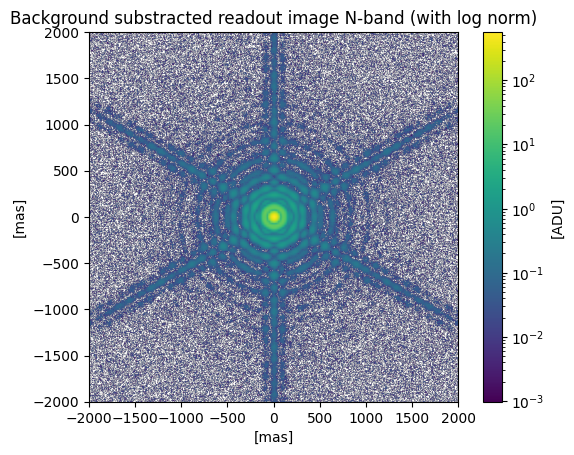

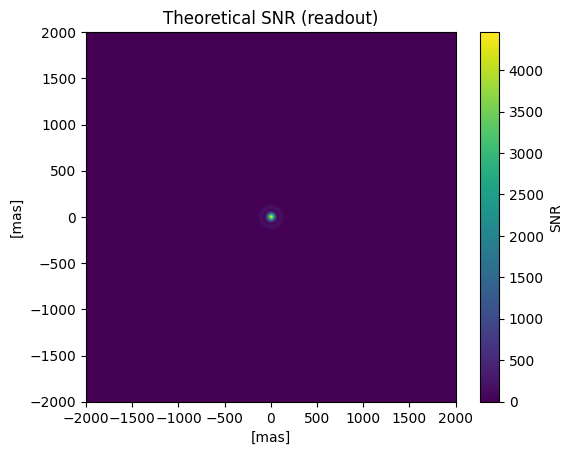

Directory '../outputs/METIS/img_n/Jy_ADU_test' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test' already exists.


In [46]:
file_1Jy = '../outputs/models/Circular_Gaussian_unres_pt_source_0.77Jy_N-band.fits'
Jy_ADU_test=SNR_calculation(file_src=file_1Jy, file_full_src=file_1Jy,
                            mode="img_n", exptime=exptime_1hour,
                            chop_nod=False,  chop_nod_offset=0*u.arcsec,
                            psf_substraction=False,  psf_file='nothing',
                            SNR_implane_plot=False, SNR_readout_plot=True, window_lim=2000,
                            contour_plot=False,
                            creating_FITs=True, object_name='Jy_ADU_test')

### With chop nod

astar.scopesim.optics.optical_train - Observing empty field


 FOVs: 100%|██████████| 3/3 [00:05<00:00,  1.87s/it]

astar.scopesim.effects.electronic - Requested exposure time: 900.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.03s/it]

Chopping: [4.5 0. ]
Nodding:  [0.  4.5]
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.07s/it]

Chopping: [4.5 0. ]
Nodding:  [0.  4.5]
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


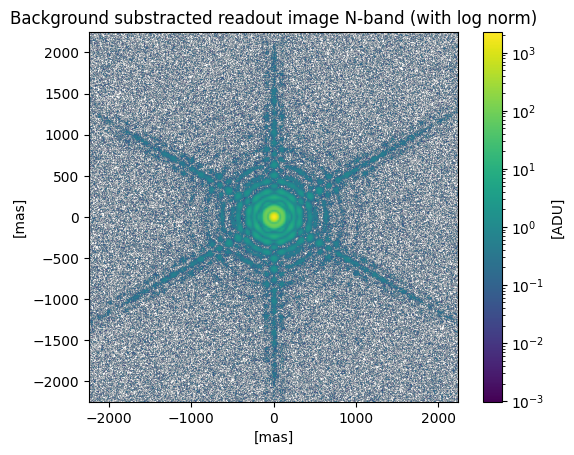

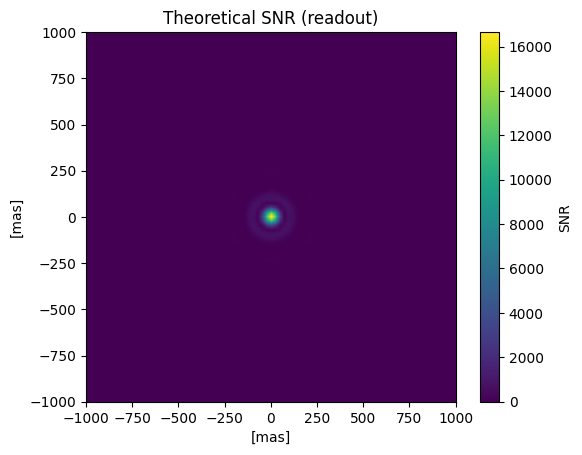

Directory '../outputs/METIS/img_n/Jy_ADU_test_chopnod' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test_chopnod' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test_chopnod' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test_chopnod' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test_chopnod' already exists.
Directory '../outputs/METIS/img_n/Jy_ADU_test_chopnod' already exists.


In [19]:
Jy_ADU_test_chopnod = SNR_calculation(file_src=file_1Jy, file_full_src=file_1Jy,
                                      mode="img_n", exptime=exptime_1hour/4,
                                      chop_nod=True,  chop_nod_offset=4.5*u.arcsec,
                                      psf_substraction=False, psf_file='nothing', 
                                      SNR_implane_plot=False, SNR_readout_plot=True, window_lim=1000,
                                      creating_FITs=True, object_name='Jy_ADU_test_chopnod')

In [ ]:
print('ADU obtained for a source of 1Jy')
print(np.sum(Jy_ADU_test[3]))
print(np.sum(Jy_ADU_test_chopnod[3]))

ADU obtained for a source of 1Jy
77539.47
305060.47


## Extension of extended source

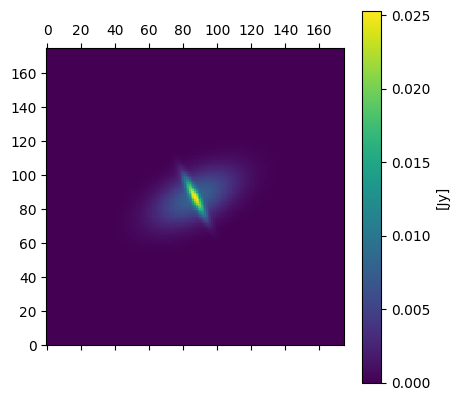

In [ ]:
# Generation of the 2D Circinus with 3 components: the unres, the disk, and the polar ones
pixel_size_circinus = 0.1*u.pc
"""pixel_size_circinus = mas_to_pc(N_band_pixel_scale, D_circinus)
print(pixel_size_circinus)"""

CDELT = 3.90625 *u.mas


pxl_polar_x = 52
pxl_polar_y = 26
pxl_disk_x = pxl_polar_y
pxl_disk_y = 5
pxl_unres_x = 3 # mettre 3


theta_polar = 27*u.degree
theta_disk = theta_polar + 90*u.degree


#FWHM_unres = mas_to_pc(pxl_unres_x*CDELT, D_circinus)
FWHM_unres = mas_to_pc(N_band_pixel_scale/2, D_circinus)
FWHM_disk_x = mas_to_pc(pxl_disk_x*CDELT, D_circinus)
FWHM_disk_y = mas_to_pc(pxl_disk_y*CDELT, D_circinus)
FWHM_polar_x = mas_to_pc(pxl_polar_x*CDELT, D_circinus)
FWHM_polar_y = mas_to_pc(pxl_polar_y*CDELT, D_circinus)

FWHM_unres , FWHM_disk_x, FWHM_disk_y , FWHM_polar_x , FWHM_polar_y 

flux_unres = 0.77*u.Jy
flux_disk = 1.61 *u.Jy
flux_polar = 7.79*u.Jy



G_extended_only_3 = create_model_3compo(FWHM_unres=0*u.pc, flux_unres=0*u.Jy,
                                              FWHM_polar_x=FWHM_polar_y, FWHM_polar_y=FWHM_polar_x, flux_polar=flux_polar, theta_polar=theta_polar,
                                              FWHM_disk_x=FWHM_disk_y, FWHM_disk_y=FWHM_disk_x, flux_disk=flux_disk, theta_disk=theta_disk,
                                              pixel_size=pixel_size_circinus, D_source=D_circinus, 
                                              grid_length_factor=10, d_offset=0,
                                              example_file=example_FITS, band_name='N', source_name="Circinus_Extended_only", 
                                              creating_FITS=True)

plt.matshow(G_extended_only_3)#, extent=[-CDELT_circinus.value*length, CDELT_circinus.value*length, -100, CDELT_circinus.value*length])
plt.ylim(0, np.shape(G_extended_only_3)[1])
plt.colorbar(label='[Jy]')
plt.show()


### Function

In [ ]:
def elliptical_annulus_mean_rotated(image, a, b, CDELT, thickness, theta, windows_lim):
    """
    Compute the mean value of pixels within a rotated elliptical annulus.

    Parameters:
    - image: 2D numpy array
    - a: semi-major axis of inner ellipse [mas]
    - b: semi-minor axis of inner ellipse [mas]
    - thickness: thickness of the annulus
    - center: tuple (cy, cx)
    - theta: rotation angle in radians (counterclockwise)

    Returns:
    - mean value within the annulus
    """
    # conversion
    a = a.to(u.mas)
    b = b.to(u.mas)
    CDELT = CDELT.to(u.mas)
    theta = theta.to(u.radian)
    windows_lim = windows_lim.to(u.mas)
    
    cy, cx = np.shape(image)
    cx /= 2
    cy /= 2
    # Inner and Outer ellipse axes
    a = int(a.value/CDELT.value) # to obtain the number of pixels
    b = int(b.value/CDELT.value)
    a_outer = a + thickness
    b_outer = b + thickness

    # Coordinate grid
    y, x = np.indices(image.shape)

    # Shift coordinates to center
    x_shift = x - cx
    y_shift = y - cy

    # Precompute trig
    cos_t = np.cos(theta.value)
    sin_t = np.sin(theta.value)

    # Rotate coordinates
    x_rot = x_shift * cos_t + y_shift * sin_t
    y_rot = -x_shift * sin_t + y_shift * cos_t

    # Ellipse equations
    inner = (x_rot**2) / a**2 + (y_rot**2) / b**2
    outer = (x_rot**2) / a_outer**2 + (y_rot**2) / b_outer**2

    # Annulus mask
    mask = (outer <= 1) & (inner >= 1)

    
    # PLOT
    masked_image = np.where(mask, image, np.nan)
    
    # change axis to mas instead of pxl
    ref_pt1 = np.shape(image)[0]/2
    ref_pt2 = np.shape(image)[1]/2
    extent_array = [-ref_pt1*CDELT.value, ref_pt1*CDELT.value, -ref_pt2*CDELT.value, ref_pt2*CDELT.value]
    
    plt.imshow(image, origin='lower', norm='log', extent=extent_array)
    plt.imshow(masked_image, cmap='Greys', origin='lower', extent=extent_array)
    #plt.colorbar(image)
    plt.title('Image with mask (with log norm)')
    plt.xlabel('[mas]')
    plt.ylabel('[mas]')
    plt.xlim(-windows_lim.value, windows_lim.value)
    plt.ylim(-windows_lim.value, windows_lim.value)
    plt.show()
    
    # return
    if not np.any(mask):
        return np.nan

    return image[mask].mean()

### Janksy

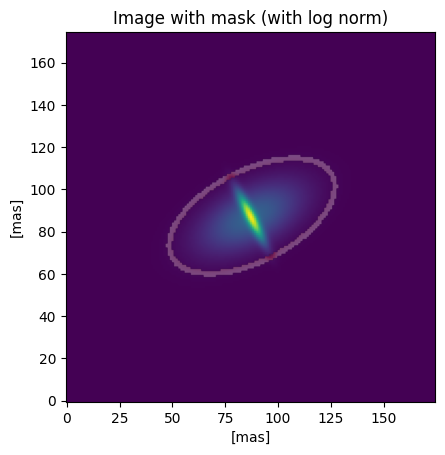

Mean on the elliptical annulus 0.0004508141518207765
Should obtain:
Without chop nod 34.95589040068255
With chop nod 137.52557703709743


In [ ]:
Jy_to_ADU = 77539.47
Jy_to_ADU_chopnod = 305060.47
FWHM_polar_x_mas = pc_to_mas(D_circinus, FWHM_polar_x)
FWHM_polar_y_mas = pc_to_mas(D_circinus, FWHM_polar_y)
CDELT_circinus = pc_to_mas(D_circinus, pixel_size_circinus)
mean_elliptical_Jy = elliptical_annulus_mean_rotated(G_extended_only_3, FWHM_polar_x_mas, FWHM_polar_y_mas, CDELT_circinus, 3, theta_polar, 150*u.mas)
print('Mean on the elliptical annulus', mean_elliptical_Jy)

print('Should obtain:')
print('Without chop nod',mean_elliptical_Jy*Jy_to_ADU)
print('With chop nod',mean_elliptical_Jy*Jy_to_ADU_chopnod)

### Observations

In [17]:
Circinus_extended_only_with_psfsub =SNR_calculation(file_src=file_circinus_extended_only, file_full_src=file_circinus_3_components_N_band,
                                      mode="img_n", exptime=exptime_1hour/4,
                                      chop_nod=False, chop_nod_offset=4.5*u.arcsec,
                                      psf_substraction=False, psf_file=file_psf_077, 
                                      SNR_implane_plot=False, SNR_readout_plot=False, window_lim=1000,
                                      creating_FITs=True, object_name='Circinus_extended_only_with_psfsub')

astar.scopesim.optics.optical_train - Observing empty field


 FOVs: 100%|██████████| 3/3 [00:05<00:00,  1.82s/it]

astar.scopesim.effects.electronic - Requested exposure time: 900.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


 FOVs: 100%|██████████| 3/3 [00:07<00:00,  2.35s/it]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


 FOVs: 100%|██████████| 3/3 [00:11<00:00,  3.68s/it]

astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub' created successfully.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub' already exists.


In [18]:
Circinus_extended_only_with_psfsub_chop_nod =SNR_calculation(file_src=file_circinus_extended_only, file_full_src=file_circinus_3_components_N_band,
                                      mode="img_n", exptime=exptime_1hour/4,
                                      chop_nod=True, chop_nod_offset=4.5*u.arcsec,
                                      psf_substraction=False, psf_file=file_psf_077, 
                                      SNR_implane_plot=False, SNR_readout_plot=False, window_lim=1000,
                                      creating_FITs=True, object_name='Circinus_extended_only_with_psfsub_chop_nod')

astar.scopesim.optics.optical_train - Observing empty field


 FOVs: 100%|██████████| 3/3 [00:05<00:00,  1.85s/it]

astar.scopesim.effects.electronic - Requested exposure time: 900.000 s
astar.scopesim.effects.electronic - Required DIT without saturation: 0.015 s
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.09s/it]

Chopping: [4.5 0. ]
Nodding:  [0.  4.5]
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s


 FOVs: 100%|██████████| 3/3 [00:06<00:00,  2.20s/it]

Chopping: [4.5 0. ]
Nodding:  [0.  4.5]
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
astar.scopesim.detector.detector_manager - Extracting from 1 detectors...


astar.scopesim.effects.electronic.electrons - Applying gain 201
astar.scopesim.effects.electronic.electrons - Applying digitization to dtype float32.
astar.scopesim.effects.electronic - Exposure parameters: DIT = 0.015 s, NDIT = 60205
astar.scopesim.effects.electronic - Total exposure time: 900.000 s
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub_chop_nod' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub_chop_nod' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub_chop_nod' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub_chop_nod' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub_chop_nod' already exists.
Directory '../outputs/METIS/img_n/Circinus_extended_only_with_psfsub_chop_nod' already exists.


### ADU

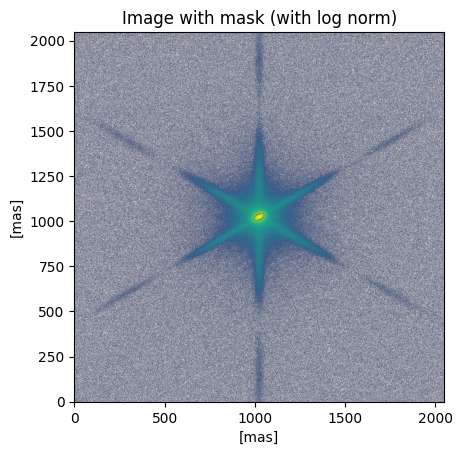

Mean on the elliptical annulus (no chop nod) 154.35287


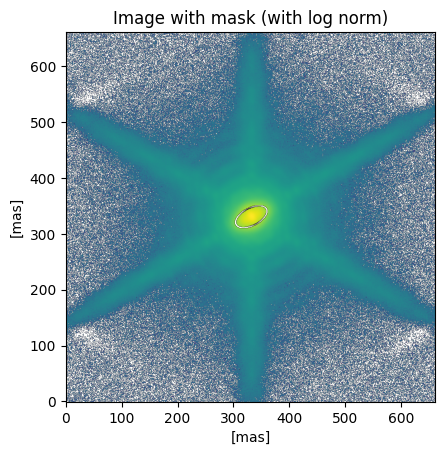

Mean on the elliptical annulus (no chop nod) 617.4164


In [35]:
mean_elliptical_ADU = elliptical_annulus_mean_rotated(Circinus_extended_only_with_psfsub[3], FWHM_polar_x_mas, FWHM_polar_y_mas, N_band_pixel_scale, 3, theta_polar, 1000*u.mas)
print('Mean on the elliptical annulus (no chop nod)', mean_elliptical_ADU)

mean_elliptical_ADU_chopnod = elliptical_annulus_mean_rotated(Circinus_extended_only_with_psfsub_chop_nod[3], FWHM_polar_x_mas, FWHM_polar_y_mas, N_band_pixel_scale, 3, theta_polar, 1000*u.mas)
print('Mean on the elliptical annulus (no chop nod)', mean_elliptical_ADU_chopnod)